# Return Predictability

In [1]:
import pandas as pd
data  = pd.read_csv("Data handling/price.csv")

# Step 1: Convert 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data = data[data['Date']<= '2020-04-29']

# Step 2: Set the date as index
data.set_index('Date', inplace=True)

# Step 3: Resample weekly and calculate mean
data = data.resample('W').mean(numeric_only=True)

## Price Time Series

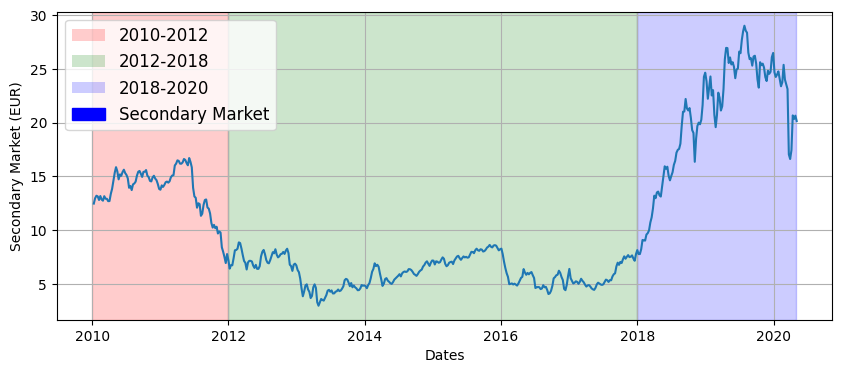

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(10, 4))
ax = sns.lineplot(x=data.index, y=data['Secondary Market'], marker='', label='Secondary Market')
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2011-12-31'), color='red', alpha=0.2)
ax.axvspan(pd.Timestamp('2012-01-01'), pd.Timestamp('2017-12-31'), color='green', alpha=0.2)
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2020-04-29'), color='blue', alpha=0.2)
legend_elements = [Patch(facecolor='red', alpha=0.2, label='2010-2012'),
                   Patch(facecolor='green', alpha=0.2, label='2012-2018'),
                   Patch(facecolor='blue', alpha=0.2, label='2018-2020'),
                   Patch(linestyle='-', color='blue', label='Secondary Market')]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12)
plt.xlabel('Dates')
plt.ylabel('Secondary Market (EUR)')
plt.grid(True)
plt.show()

## Return Time Series

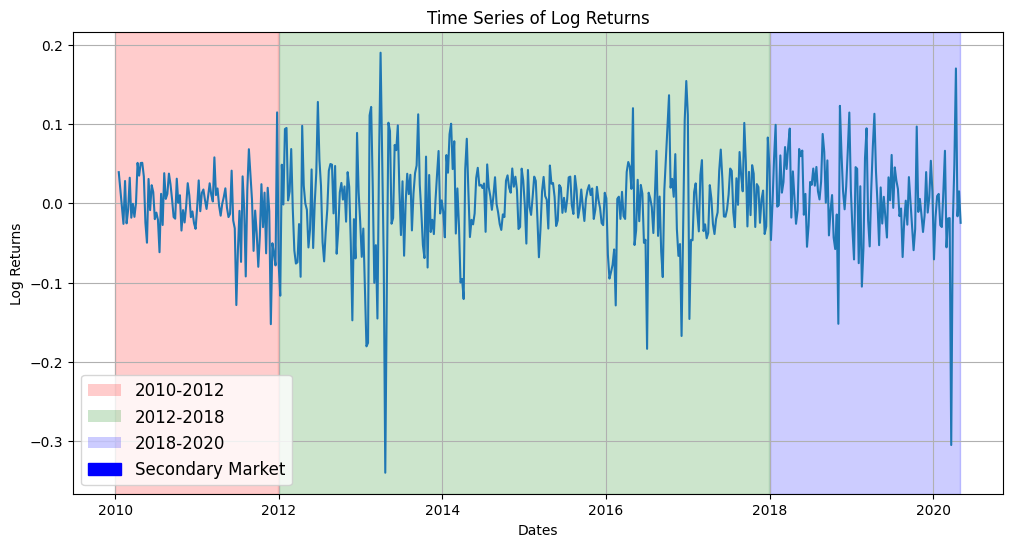

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data['returns'] = (np.log(data['Secondary Market']).diff())

plt.figure(figsize=(12, 6))

ax =sns.lineplot(x=data.index, y=data.returns, marker='')
ax.axvspan(pd.Timestamp('2010-01-01'), pd.Timestamp('2011-12-31'), color='red', alpha=0.2)
ax.axvspan(pd.Timestamp('2012-01-01'), pd.Timestamp('2017-12-31'), color='green', alpha=0.2)
ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2020-04-29'), color='blue', alpha=0.2)
legend_elements = [Patch(facecolor='red', alpha=0.2, label='2010-2012'),
                   Patch(facecolor='green', alpha=0.2, label='2012-2018'),
                   Patch(facecolor='blue', alpha=0.2, label='2018-2020'),
                   Patch(linestyle='-', color='blue', label='Secondary Market')]
ax.legend(handles=legend_elements, loc='lower left', fontsize = 12)

plt.title('Time Series of Log Returns')
plt.xlabel('Dates')
plt.ylabel('Log Returns')
plt.grid(True)
plt.savefig('pyplots/returns.png', bbox_inches='tight')
plt.show()

# Summary

* **Period 2 exhibits statistically significant dependence in both the conditional mean and conditional variance**. In contrast, **Periods 1 and 3 do not display comparable dependence structures**.

* **The predictability observed in Period 2** is consistent with the findings discussed in the later sections of the paper.

* **The estimated confidence intervals for the AR and GARCH parameters are informative and well-identified**, supporting the presence of predictability in Period 2 while offering limited evidence in the other periods.

* **Model diagnostics suggest that the standardized residuals are close to white noise**, indicating that the AR(4)-GARCH(1,1) specification adequately captures the dynamics of the return series.

# Analysis
## ADF Tests on the Periods

In [10]:
from statsmodels.tsa.stattools import adfuller

r1 = data['returns'][data.index<pd.Timestamp('2011-12-31')][1:].dropna()
r2 = data['returns'][(data.index>=pd.Timestamp('2012-01-01')) & (data.index<pd.Timestamp('2017-12-31'))].dropna()
r3 = data['returns'][data.index>=pd.Timestamp('2018-01-01')].dropna()

result_adf = adfuller(r1)
print('ADF Statistic for period 1:', round(result_adf[0],2))
print('p-value:', result_adf[1])

if result_adf[1] < 0.05:
    print("The series is stationary in mean (reject H₀).")
else:
    print("The series is not stationary in mean (fail to reject H₀).")

result_adf = adfuller(r2)
print('\nADF Statistic for period 2:', round(result_adf[0],2))
print('p-value:', result_adf[1])

if result_adf[1] < 0.05:
    print("The series is stationary in mean (reject H₀).")
else:
    print("The series is not stationary in mean (fail to reject H₀).")

result_adf = adfuller(r3)
print('\nADF Statistic for period 3:', round(result_adf[0],2))
print('p-value:', result_adf[1])

if result_adf[1] < 0.05:
    print("The series is stationary in mean (reject H₀).")
else:
    print("The series is not stationary in mean (fail to reject H₀).")

ADF Statistic for period 1: -5.13
p-value: 1.204282572743136e-05
The series is stationary in mean (reject H₀).

ADF Statistic for period 2: -7.79
p-value: 8.186503604642024e-12
The series is stationary in mean (reject H₀).

ADF Statistic for period 3: -7.11
p-value: 4.0402084629306363e-10
The series is stationary in mean (reject H₀).


## ARCH Tests on the Periods

In [11]:
from statsmodels.stats.diagnostic import het_arch

# lag=12 is common; adjust based on your data
arch_test = het_arch(r1, nlags=12)

print("ARCH Test Statistic for Period 1:", round(arch_test[0],2))
print("p-value:", arch_test[1])

if arch_test[1] < 0.01:
    print("ARCH effects are present, variance is not stationary (reject H₀).")
else:
    print("No ARCH effects, variance is likely stationary (fail to reject H₀).")

arch_test = het_arch(r2, nlags=12)

print("\nARCH Test Statistic for Period 2:", round(arch_test[0],2))
print("p-value:", arch_test[1])

if arch_test[1] < 0.01:
    print("ARCH effects are present, variance is not stationary (reject H₀).")
else:
    print("No ARCH effects, variance is likely stationary (fail to reject H₀).")

arch_test = het_arch(r3, nlags=12)

print("\nARCH Test Statistic for Period 3:", round(arch_test[0],2))
print("p-value:", arch_test[1])

if arch_test[1] < 0.01:
    print("ARCH effects are present, variance is not stationary (reject H₀).")
else:
    print("No ARCH effects, variance is likely stationary (fail to reject H₀).")

ARCH Test Statistic for Period 1: 24.07
p-value: 0.019899363183158228
No ARCH effects, variance is likely stationary (fail to reject H₀).

ARCH Test Statistic for Period 2: 39.83
p-value: 7.66498172959199e-05
ARCH effects are present, variance is not stationary (reject H₀).

ARCH Test Statistic for Period 3: 10.01
p-value: 0.6149621814371851
No ARCH effects, variance is likely stationary (fail to reject H₀).


## Available Data

In [12]:
print(f'Length of the timeseries in Period 1: {len(r1)}, Period 2: {len(r2)}, Period 3: {len(r3)}')

Length of the timeseries in Period 1: 102, Period 2: 313, Period 3: 122


## Ljung-Box Tests on Returns and Squared Returns

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test(r, lags=12, label=""):
    lb = acorr_ljungbox(r, lags=lags, return_df=True)
    
    print(f"\n{label}, Ljung-Box test on RETURNS")
    print("Q-stat:", round(lb['lb_stat'].iloc[-1], 2))
    print("p-value:", round(lb['lb_pvalue'].iloc[-1], 4))
    
    if lb['lb_pvalue'].iloc[-1] < 0.01:
        print("Reject H₀: linear dependence present")
    else:
        print("Fail to reject H₀: no linear predictability")

def ljung_box_squared(r, lags=12, label=""):
    lb = acorr_ljungbox(r**2, lags=lags, return_df=True)
    
    print(f"\n{label}, Ljung-Box test on SQUARED RETURNS")
    print("Q-stat:", round(lb['lb_stat'].iloc[-1], 2))
    print("p-value:", round(lb['lb_pvalue'].iloc[-1], 4))
    
    if lb['lb_pvalue'].iloc[-1] < 0.01:
        print("Reject H₀: volatility clustering present")
    else:
        print("Fail to reject H₀: no volatility clustering")

# Run for your periods
ljung_box_test(r1, label="Period 1")
ljung_box_squared(r1, label="Period 1")

ljung_box_test(r2, label="Period 2")
ljung_box_squared(r2, label="Period 2")

ljung_box_test(r3, label="Period 3")
ljung_box_squared(r3, label="Period 3")



Period 1, Ljung-Box test on RETURNS
Q-stat: 14.81
p-value: 0.2518
Fail to reject H₀: no linear predictability

Period 1, Ljung-Box test on SQUARED RETURNS
Q-stat: 22.58
p-value: 0.0315
Fail to reject H₀: no volatility clustering

Period 2, Ljung-Box test on RETURNS
Q-stat: 79.16
p-value: 0.0
Reject H₀: linear dependence present

Period 2, Ljung-Box test on SQUARED RETURNS
Q-stat: 80.34
p-value: 0.0
Reject H₀: volatility clustering present

Period 3, Ljung-Box test on RETURNS
Q-stat: 14.56
p-value: 0.2665
Fail to reject H₀: no linear predictability

Period 3, Ljung-Box test on SQUARED RETURNS
Q-stat: 7.77
p-value: 0.8026
Fail to reject H₀: no volatility clustering


# ARMA-GARCH Modelling

# Period 1

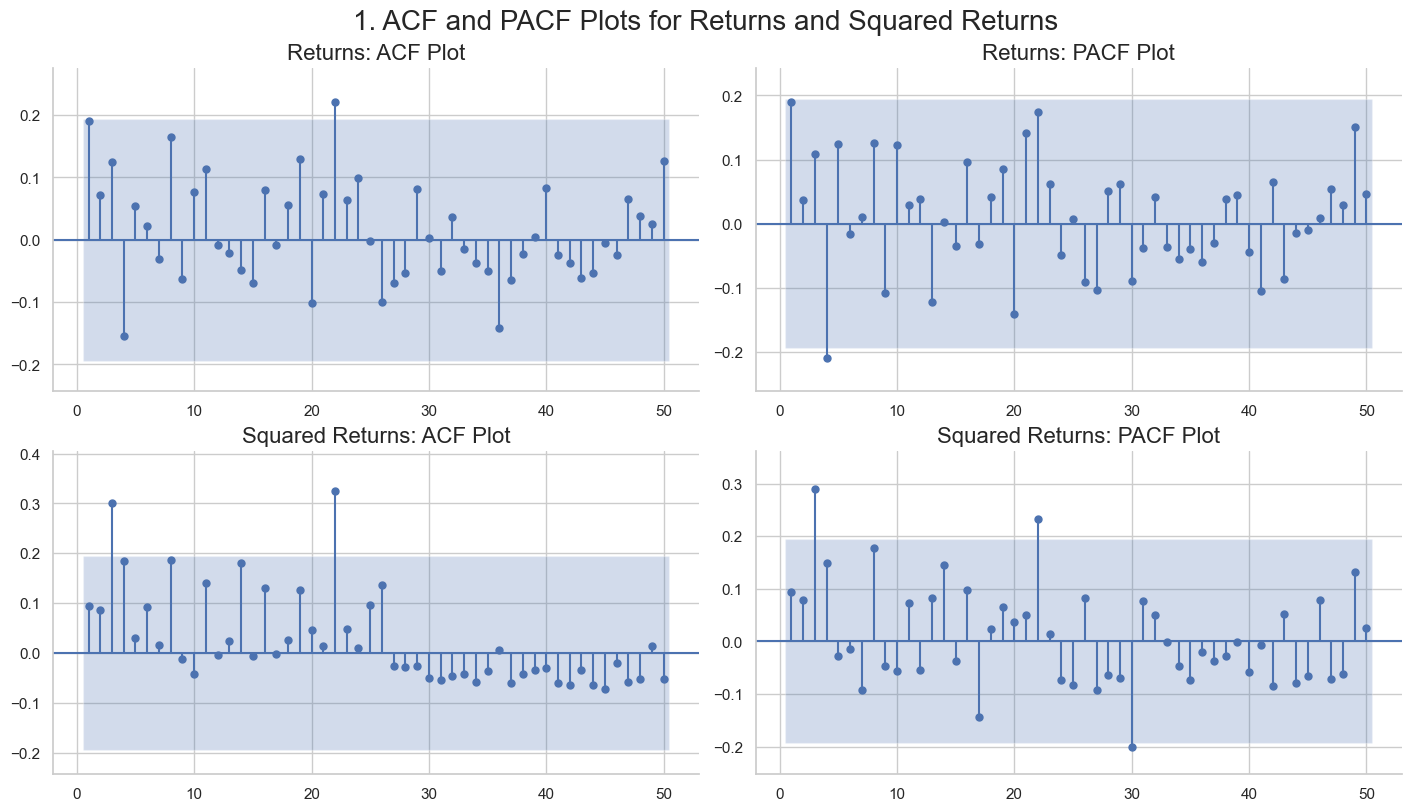

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(r1, lags=50, alpha=0.05, ax=axes[0,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0,0].set_title("Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r1, lags=50, alpha=0.05, ax=axes[0,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0,1].set_title("Returns: PACF Plot", fontsize=16)

# ACF of returns
plot_acf(r1**2, lags=50, alpha=0.05, ax=axes[1,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1,0].set_title("Squared Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r1**2, lags=50, alpha=0.05, ax=axes[1,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1,1].set_title("Squared Returns: PACF Plot", fontsize=16)
# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("1. ACF and PACF Plots for Returns and Squared Returns", fontsize=20)
plt.savefig('pyplots/acf-pacf1.png')
plt.show()

In [30]:
from arch import arch_model 
from statsmodels.tsa.arima.model import ARIMA
from warnings import filterwarnings
import numpy as np
import matplotlib.pyplot as plt
filterwarnings("ignore")
from itertools import combinations, product
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

def arma_fit(r, ar_lags, ma_lags,verbose=False, label=""):
    """
    Fit ARMA model with ONLY specified AR and MA lags non-zero.
    All other lags are constrained to zero.
    Returns residuals and 1-period ahead forecast.
    """

    max_ar = max(ar_lags) if ar_lags else 0
    max_ma = max(ma_lags) if ma_lags else 0

    model = SARIMAX(
        r,
        order=(max_ar, 0, max_ma),
        trend='n',
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    # Build parameter constraints as a dictionary
    constraints = {}
    param_names = model.param_names

    for name in param_names:
        # AR terms
        if name.startswith("ar.L"):
            lag = int(name.split("L")[1])
            if lag not in ar_lags:
                constraints[name] = 0.0

        # MA terms
        if name.startswith("ma.L"):
            lag = int(name.split("L")[1])
            if lag not in ma_lags:
                constraints[name] = 0.0

    res = model.fit_constrained(constraints, disp=False)

    if verbose:
        print(f"\n{label} – ARMA with AR lags {ar_lags}, MA lags {ma_lags}")
        print(res.summary())

    # Return residuals and 1-period ahead forecast
    forecast_1step = res.forecast(steps=1).iloc[0]
    
    return res.resid, forecast_1step


def garch_fit(residuals, p, q,verbose = False, label=""):
    """
    Fit GARCH model to residuals.
    Returns standardized residuals and 1-period ahead volatility forecast.
    """
    # Fit GARCH to residuals
    garch_model = arch_model(
        residuals,
        mean='Zero',
        vol='GARCH',
        p=p, 
        q=q,
        dist='normal'
    )
    garch_res = garch_model.fit(disp='off')
    
    if verbose:
        print(f"\n{label} – GARCH({p},{q}) Summary")
        print(garch_res.summary())
    
    # Return standardized residuals and 1-period ahead volatility forecast
    std_resid = garch_res.std_resid
    volatility_forecast = garch_res.forecast(horizon=1).variance.iloc[-1, 0] ** 0.5
    
    return std_resid, volatility_forecast


def rolling_arma_garch_forecasts(r, ar_lags, ma_lags, p, q, window=20):
    """
    Rolling one-step-ahead forecasts using two-step ARMA-GARCH
    Returns mean forecasts, variance forecasts, and actuals
    """
    mean_fc = []
    var_fc = []
    actuals = []

    for t in range(window, len(r)):
        train = r[t-window:t]

        try:
            # Step 1: Fit ARMA using your arma_fit function
            arma_residuals, arma_forecast = arma_fit(
                train, 
                ar_lags=ar_lags, 
                ma_lags=ma_lags, 
                label=""  # Silent mode for rolling
            )
            
            # Step 2: Fit GARCH to ARMA residuals using your garch_fit function
            std_resid, vol_forecast = garch_fit(
                arma_residuals, 
                p=p, 
                q=q, 
                label=""  # Silent mode for rolling
            )
            
            # Store forecasts
            mean_fc.append(arma_forecast)
            var_fc.append(vol_forecast ** 2)  # Convert std dev to variance
            actuals.append(r.iloc[t])
            
        except Exception as e:
            # If model fails, skip this iteration
            print(f"Warning: Failed at t={t}, error: {e}")
            continue

    return (
        np.array(mean_fc),
        np.array(var_fc),
        np.array(actuals)
    )


def directional_accuracy(mean_fc, actuals):
    """Calculate directional accuracy"""
    sign_fc = np.sign(mean_fc)
    sign_act = np.sign(actuals)

    valid = (sign_fc != 0) & (sign_act != 0)
    hits = sign_fc[valid] == sign_act[valid]

    da = np.mean(hits) if np.any(valid) else 0.0

    return da, hits, valid


def interval_hit_rate(mean_fc, var_fc, actuals, k=2):
    """
    Calculate hit rate: % of actuals within ±k standard deviations
    
    Parameters:
    -----------
    mean_fc : array
        Mean forecasts
    var_fc : array
        Variance forecasts
    actuals : array
        Actual values
    k : float
        Number of standard deviations (default=2 for 95% interval)
    
    Returns:
    --------
    hit_rate : float
        Proportion of actuals within the interval
    inside : array
        Boolean array indicating which actuals are inside the interval
    """
    std_fc = np.sqrt(var_fc)
    lower_bound = mean_fc - k * std_fc
    upper_bound = mean_fc + k * std_fc
    
    inside = (actuals >= lower_bound) & (actuals <= upper_bound)
    hit_rate = np.mean(inside)
    
    return hit_rate, inside


def plot_arma_garch_forecasts(r, ar_lags, ma_lags, p, q, window=20, 
                               title="Rolling ARMA-GARCH Forecast", n_plot=20):
    """
    Plot last n_plot forecasts from rolling ARMA-GARCH model
    """
    mean_fc, var_fc, actuals = rolling_arma_garch_forecasts(
        r, ar_lags, ma_lags, p, q, window
    )

    # Directional accuracy (full sample)
    da, hits, valid = directional_accuracy(mean_fc, actuals)
    
    # Hit rate (full sample)
    hr, inside = interval_hit_rate(mean_fc, var_fc, actuals, k=2)

    # Keep last n_plot for plotting
    mean_fc2 = mean_fc[-n_plot:]
    var_fc2 = var_fc[-n_plot:]
    actuals2 = actuals[-n_plot:]

    std_fc = np.sqrt(var_fc2)
    x = np.arange(len(mean_fc2))

    plt.figure(figsize=(11, 5))

    plt.plot(x, actuals2, marker='o', label="Actual Returns", linewidth=1.5)
    plt.plot(x, mean_fc2, linestyle='--', marker='s', 
             label="Forecasted Mean", linewidth=1.5)

    plt.fill_between(
        x,
        mean_fc2 - 2 * std_fc,
        mean_fc2 + 2 * std_fc,
        alpha=0.25,
        label="±2 Conditional Std Dev"
    )

    plt.title(f"{title}\nDirectional Accuracy = {da:.2%} | Hit Rate (±2σ) = {hr:.2%}", 
              fontsize=12)
    plt.xlabel("Rolling Forecast Index", fontsize=10)
    plt.ylabel("Return", fontsize=10)
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'pyplots/{title[:8]}.png')
    plt.show()

    print(f"\nFull Sample Metrics:")
    print(f"Directional Accuracy: {da:.2%}")
    print(f"Hit Rate (±2σ): {hr:.2%}")
    print(f"Total forecasts: {len(mean_fc)}")

    return da, hr, mean_fc2, var_fc2, actuals2


def cross_validate_arma_garch(r, candidate_ar_lags, candidate_ma_lags,
                               garch_orders=[(1,1)], window=20,
                               verbose=True):
    """
    Cross-validation for ARMA-GARCH using rolling window forecasts.

    Rolls over the full series; forecasts at t use r[t-window:t] as training.
    Forecasts for t < split  → train evaluation (model selection).
    Forecasts for t >= split → test evaluation (out-of-sample performance).

    Parameters
    ----------
    r : pd.Series
        Return series.
    candidate_ar_lags : list
        e.g. [1, 4] — all non-empty subsets will be tried, plus empty.
    candidate_ma_lags : list
        e.g. [1, 2] — all non-empty subsets will be tried, plus empty.
    garch_orders : list of (p, q) tuples
        e.g. [(1,1)].
    window : int
        Rolling window size for ARMA-GARCH fitting.
    verbose : bool
        Print progress and results table.

    Returns
    -------
    best_spec : dict
        Best model spec with train/test DA and hit rate.
    results_df : pd.DataFrame
        Full results table sorted by train directional accuracy.
    """

    n = len(r)
    split = int(n * 0.8)

    if verbose:
        print(f"Series length  : {n}")
        print(f"Train samples  : {split}  (indices 0–{split-1})")
        print(f"Test  samples  : {n - split}  (indices {split}–{n-1})")
        print(f"Rolling window : {window}\n")

    # ------------------------------------------------------------------ #
    # Build all lag-subset combinations
    # ------------------------------------------------------------------ #
    def all_subsets(lags):
        subsets = [[]]
        for size in range(1, len(lags) + 1):
            for combo in combinations(lags, size):
                subsets.append(list(combo))
        return subsets

    ar_subsets = all_subsets(candidate_ar_lags)
    ma_subsets = all_subsets(candidate_ma_lags)

    specs = [(ar, ma, gp, gq)
             for ar, ma in product(ar_subsets, ma_subsets)
             for gp, gq in garch_orders]

    if verbose:
        print(f"Total specifications to evaluate: {len(specs)}\n")

    # ------------------------------------------------------------------ #
    # Core rolling function — splits forecasts into train / test buckets
    # ------------------------------------------------------------------ #
    def rolling_forecasts_full(r, ar_lags, ma_lags, p, q, window, split):
        """
        Roll over the full series.
        Each forecast at t uses r[t-window : t] as the fitting window.
        t < split  → train bucket
        t >= split → test bucket
        """
        mean_fc_train, var_fc_train, act_train = [], [], []
        mean_fc_test,  var_fc_test,  act_test  = [], [], []

        for t in range(window, len(r)):
            train_slice = r.iloc[t - window: t]
            try:
                arma_resid, arma_fc = arma_fit(
                    train_slice, ar_lags=ar_lags, ma_lags=ma_lags
                )
                _, vol_fc = garch_fit(arma_resid, p=p, q=q)

                actual = r.iloc[t]
                if t < split:
                    mean_fc_train.append(arma_fc)
                    var_fc_train.append(vol_fc ** 2)
                    act_train.append(actual)
                else:
                    mean_fc_test.append(arma_fc)
                    var_fc_test.append(vol_fc ** 2)
                    act_test.append(actual)

            except Exception as e:
                print(f"  Warning: Failed at t={t}: {e}")
                continue

        return (
            np.array(mean_fc_train), np.array(var_fc_train), np.array(act_train),
            np.array(mean_fc_test),  np.array(var_fc_test),  np.array(act_test)
        )

    # ------------------------------------------------------------------ #
    # Evaluate all specs
    # ------------------------------------------------------------------ #
    records = []
    for idx, (ar, ma, gp, gq) in enumerate(specs):
        label = f"AR{ar}-MA{ma}-GARCH({gp},{gq})"
        try:
            mtr, vtr, atr, mte, vte, ate = rolling_forecasts_full(
                r, ar, ma, gp, gq, window, split
            )
            if len(mtr) == 0:
                raise ValueError("No train forecasts produced.")

            train_da, _, _ = directional_accuracy(mtr, atr)

            records.append({
                'ar_lags' : ar,
                'ma_lags' : ma,
                'garch_p' : gp,
                'garch_q' : gq,
                'train_da': train_da,
                'label'   : label,
                '_mte'    : mte,
                '_vte'    : vte,
                '_ate'    : ate,
            })

            if verbose:
                print(f"[{idx+1:>3}/{len(specs)}] {label:<35} Train DA = {train_da:.2%}")

        except Exception as e:
            if verbose:
                print(f"[{idx+1:>3}/{len(specs)}] {label:<35} FAILED: {e}")

    if not records:
        raise RuntimeError("All specifications failed.")

    results_df = pd.DataFrame(records).sort_values('train_da', ascending=False)
    results_df = results_df.reset_index(drop=True)

    # ------------------------------------------------------------------ #
    # Compute test DA and hit rate for ALL specs from cached arrays
    # ------------------------------------------------------------------ #
    test_das, test_hrs, test_nobs = [], [], []

    for _, row in results_df.iterrows():
        mte, vte, ate = row['_mte'], row['_vte'], row['_ate']
        if len(mte) == 0:
            test_das.append(None)
            test_hrs.append(None)
            test_nobs.append(0)
        else:
            da, _, _ = directional_accuracy(mte, ate)
            hr, _    = interval_hit_rate(mte, vte, ate, k=2)
            test_das.append(round(da, 6))
            test_hrs.append(round(hr, 6))
            test_nobs.append(len(ate))

    results_df['test_da']       = test_das
    results_df['test_hit_rate'] = test_hrs
    results_df['test_nobs']     = test_nobs

    # Drop cached arrays
    results_df = results_df.drop(columns=['_mte', '_vte', '_ate'])

    # ------------------------------------------------------------------ #
    # Best spec summary
    # ------------------------------------------------------------------ #
    best = results_df.iloc[0]
    best_spec = {
        'ar_lags'      : best['ar_lags'],
        'ma_lags'      : best['ma_lags'],
        'garch_p'      : best['garch_p'],
        'garch_q'      : best['garch_q'],
        'train_da'     : best['train_da'],
        'test_da'      : best['test_da'],
        'test_hit_rate': best['test_hit_rate'],
        'test_nobs'    : best['test_nobs'],
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"Best spec       : AR{best['ar_lags']}-MA{best['ma_lags']}"
              f"-GARCH({best['garch_p']},{best['garch_q']})")
        print(f"Train DA        : {best['train_da']:.2%}")
        print(f"Test  DA        : {best['test_da']:.2%}  "
              f"({best['test_nobs']} test forecasts)")
        print(f"Test  Hit Rate  : {best['test_hit_rate']:.2%}  (±2σ interval)")
        print(f"{'='*60}")
        print(f"\nAll specs by Train DA:")
        print(
            results_df[['label', 'train_da', 'test_da', 'test_hit_rate', 'test_nobs']]
            .to_string(index=False)
        )

    return best_spec, results_df


Period 1 – ARMA with AR lags [1, 4], MA lags 0
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  102
Model:               SARIMAX(4, 0, 0)   Log Likelihood                 181.581
Date:                Wed, 18 Mar 2026   AIC                           -357.162
Time:                        12:15:32   BIC                           -349.407
Sample:                    01-17-2010   HQIC                          -354.025
                         - 12-25-2011                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
ar.L1             0.2660      0.123      2.164      0.030       0.025       0.507
ar.L2 (fixed)          0        nan        nan        nan         nan     

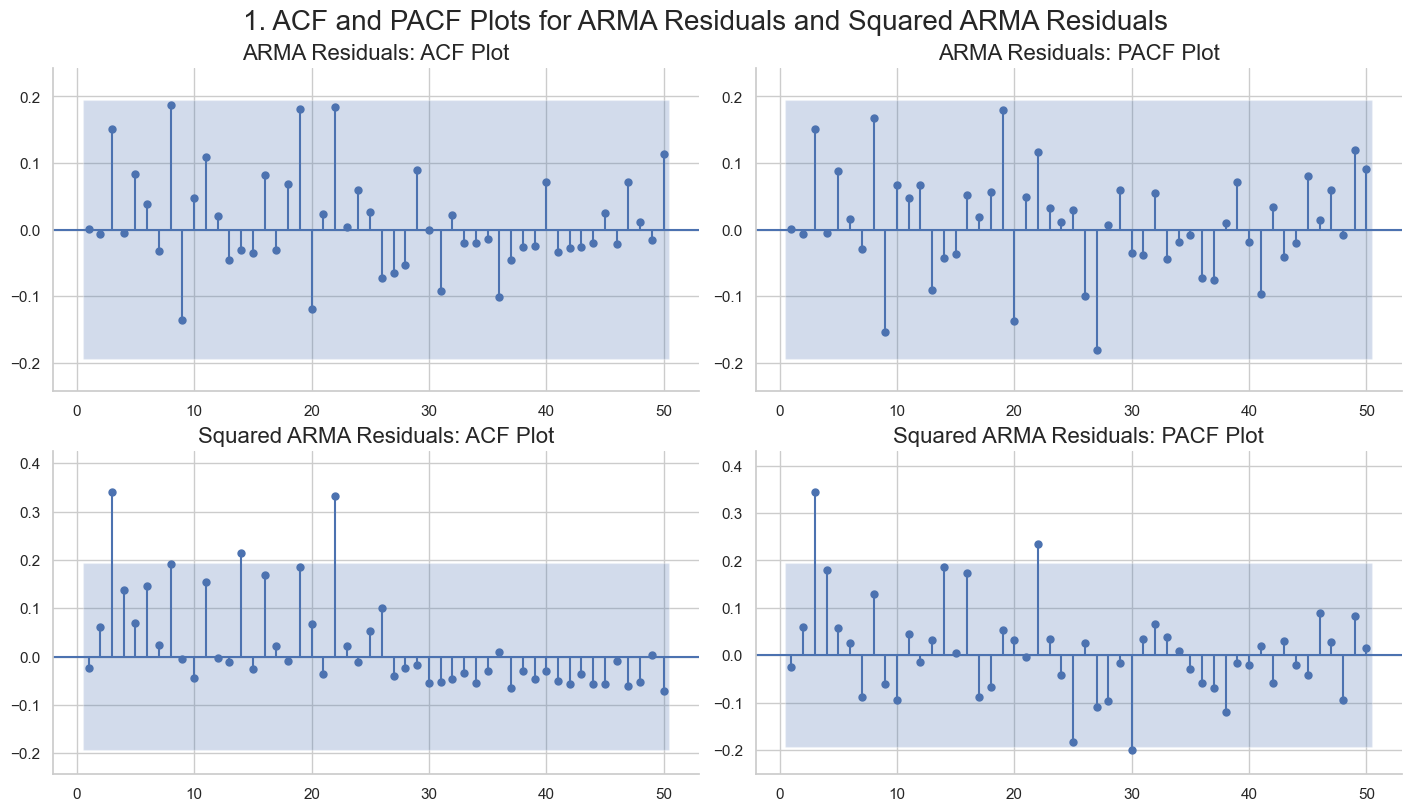

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals, forecast_1step = arma_fit(
    r1, ar_lags=[1,4], ma_lags=0,verbose=True, label="Period 1"
)

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(residuals, lags=50, alpha=0.05, ax=axes[0, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0, 0].set_title("ARMA Residuals: ACF Plot", fontsize=16)

# PACF of ARMA Residuals
plot_pacf(residuals, lags=50, alpha=0.05, ax=axes[0, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0, 1].set_title("ARMA Residuals: PACF Plot", fontsize=16)

# ACF of squared ARMA Residuals
plot_acf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1, 0].set_title("Squared ARMA Residuals: ACF Plot", fontsize=16)

# PACF of squared ARMA Residuals
plot_pacf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1, 1].set_title("Squared ARMA Residuals: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("1. ACF and PACF Plots for ARMA Residuals and Squared ARMA Residuals", fontsize=20)
plt.show()


Period 1 – GARCH(1,1) Summary
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.010
Vol Model:                      GARCH   Log-Likelihood:                198.857
Distribution:                  Normal   AIC:                          -391.713
Method:            Maximum Likelihood   BIC:                          -383.838
                                        No. Observations:                  102
Date:                Wed, Mar 18 2026   Df Residuals:                      102
Time:                        12:15:36   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      2.8106e-05  2

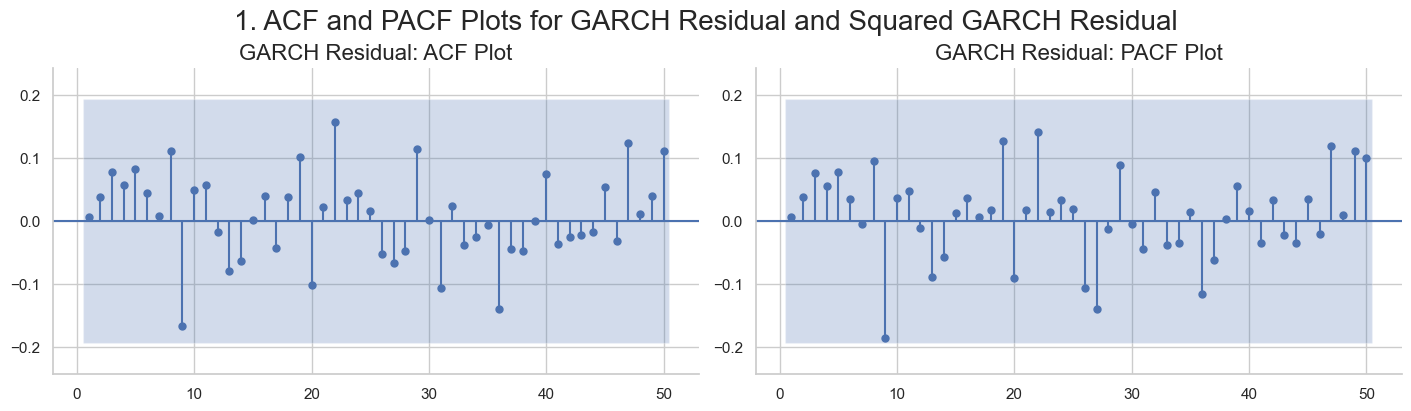

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
resid, vol1forecast = garch_fit(residuals, p =1, q=1, verbose=True, label="Period 1")

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# ACF of GARCH Residual
plot_acf(resid, lags=50, alpha=0.05, ax=axes[0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0].set_title("GARCH Residual: ACF Plot", fontsize=16)

# PACF of GARCH Residual
plot_pacf(resid, lags=50, alpha=0.05, ax=axes[1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1].set_title("GARCH Residual: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("1. ACF and PACF Plots for GARCH Residual and Squared GARCH Residual", fontsize=20)
plt.show()

## Rolling Window

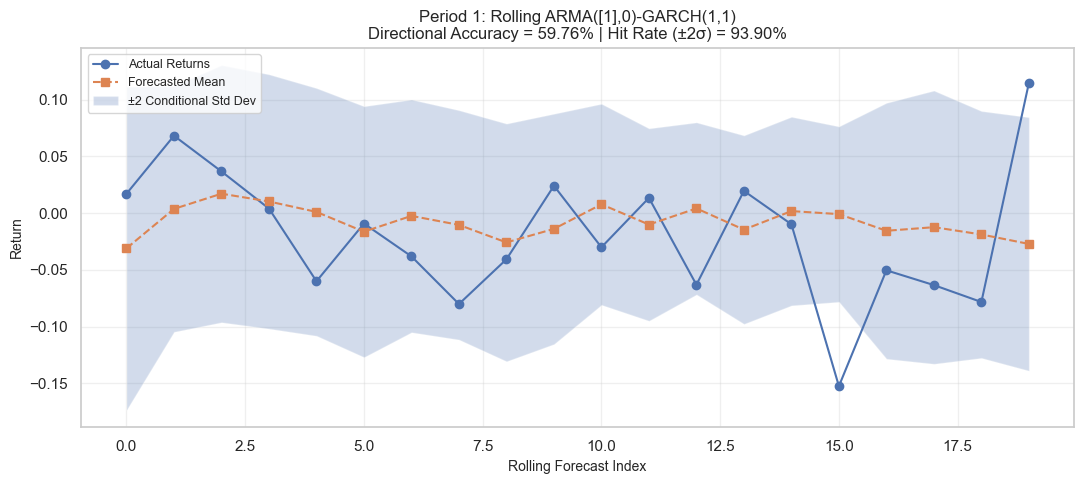


Full Sample Metrics:
Directional Accuracy: 59.76%
Hit Rate (±2σ): 93.90%
Total forecasts: 82


In [32]:
something = plot_arma_garch_forecasts(
    r1, ar_lags=[1], ma_lags=0, p=1, q=1, window=20,
    title="Period 1: Rolling ARMA([1],0)-GARCH(1,1)")

## Cross-Validation

In [13]:
# After your arma_fit / garch_fit / plot calls, run CV:
best_spec, cv_results = cross_validate_arma_garch(
    r1,
    candidate_ar_lags = [1,2,3,4],   # subsets tried: [], [1], [4], [1,4]
    candidate_ma_lags = [],        # no MA candidates → only [] tried
    garch_orders      = [(1, 1)],  # as per your use-case
    window            = 20,
    verbose           = True
)

Series length  : 102
Train samples  : 81  (indices 0–80)
Test  samples  : 21  (indices 81–101)
Rolling window : 20

Total specifications to evaluate: 16

[  1/16] AR[]-MA[]-GARCH(1,1)                Train DA = 0.00%
[  2/16] AR[1]-MA[]-GARCH(1,1)               Train DA = 60.66%
[  3/16] AR[2]-MA[]-GARCH(1,1)               Train DA = 42.62%
[  4/16] AR[3]-MA[]-GARCH(1,1)               Train DA = 44.26%
[  5/16] AR[4]-MA[]-GARCH(1,1)               Train DA = 57.38%
[  6/16] AR[1, 2]-MA[]-GARCH(1,1)            Train DA = 54.10%
[  7/16] AR[1, 3]-MA[]-GARCH(1,1)            Train DA = 54.10%
[  8/16] AR[1, 4]-MA[]-GARCH(1,1)            Train DA = 60.66%
[  9/16] AR[2, 3]-MA[]-GARCH(1,1)            Train DA = 36.07%
[ 10/16] AR[2, 4]-MA[]-GARCH(1,1)            Train DA = 50.82%
[ 11/16] AR[3, 4]-MA[]-GARCH(1,1)            Train DA = 42.62%
[ 12/16] AR[1, 2, 3]-MA[]-GARCH(1,1)         Train DA = 49.18%
[ 13/16] AR[1, 2, 4]-MA[]-GARCH(1,1)         Train DA = 55.74%
[ 14/16] AR[1, 3, 4]-MA[]-GA

# Period 2

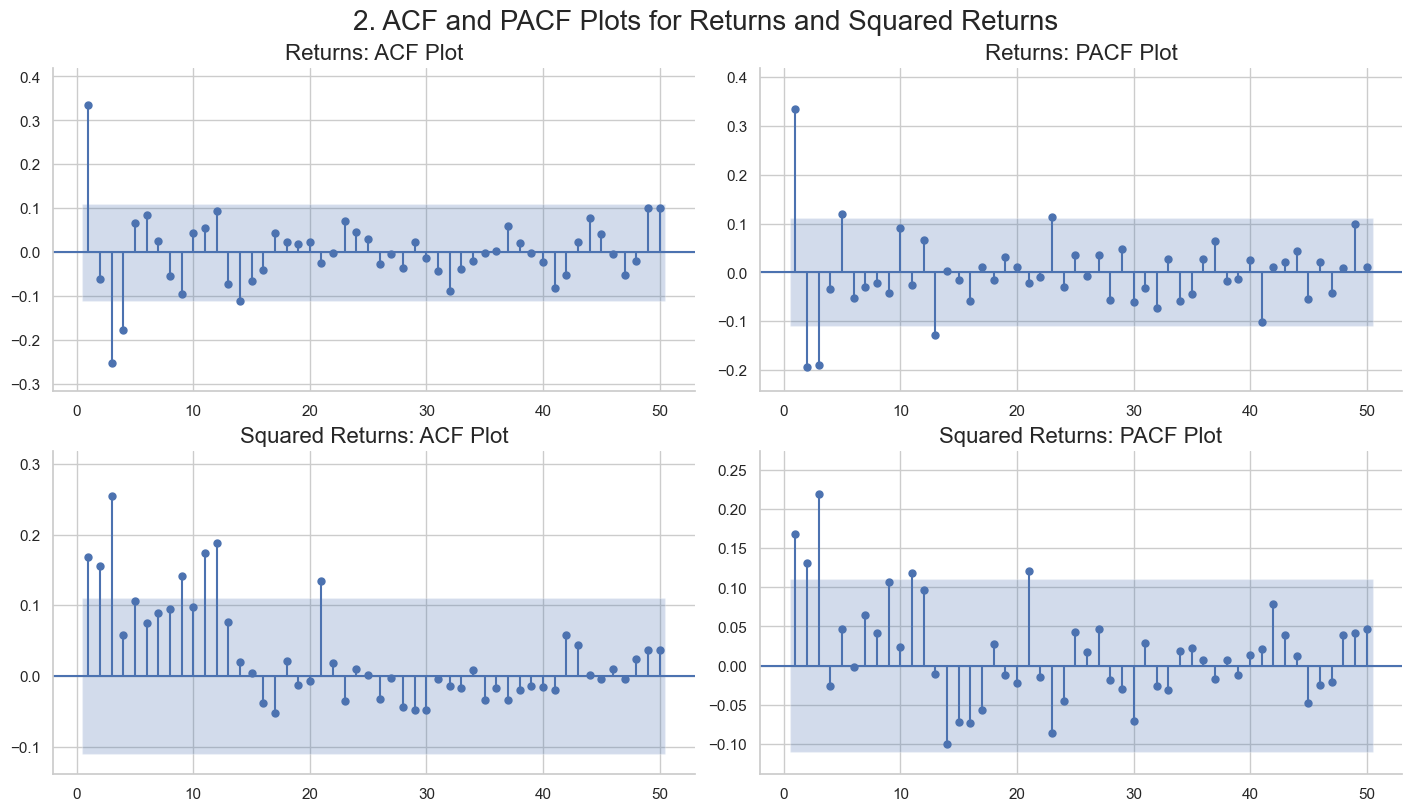

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set seaborn theme
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(r2, lags=50, alpha=0.05, ax=axes[0,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0,0].set_title("Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r2, lags=50, alpha=0.05, ax=axes[0,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0,1].set_title("Returns: PACF Plot", fontsize=16)

# ACF of returns
plot_acf(r2**2, lags=50, alpha=0.05, ax=axes[1,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1,0].set_title("Squared Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r2**2, lags=50, alpha=0.05, ax=axes[1,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1,1].set_title("Squared Returns: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("2. ACF and PACF Plots for Returns and Squared Returns", fontsize=20)
plt.savefig('pyplots/acf-pacf2.png')
plt.show()


Period 2 – ARMA with AR lags [1, 2, 3], MA lags 0
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  313
Model:               SARIMAX(3, 0, 0)   Log Likelihood                 473.577
Date:                Thu, 19 Feb 2026   AIC                           -939.153
Time:                        13:33:13   BIC                           -924.207
Sample:                    01-01-2012   HQIC                          -933.178
                         - 12-24-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3674      0.051      7.198      0.000       0.267       0.467
ar.L2         -0.1139      0.051     -2.223      0.026      -0.214      -0.013
a

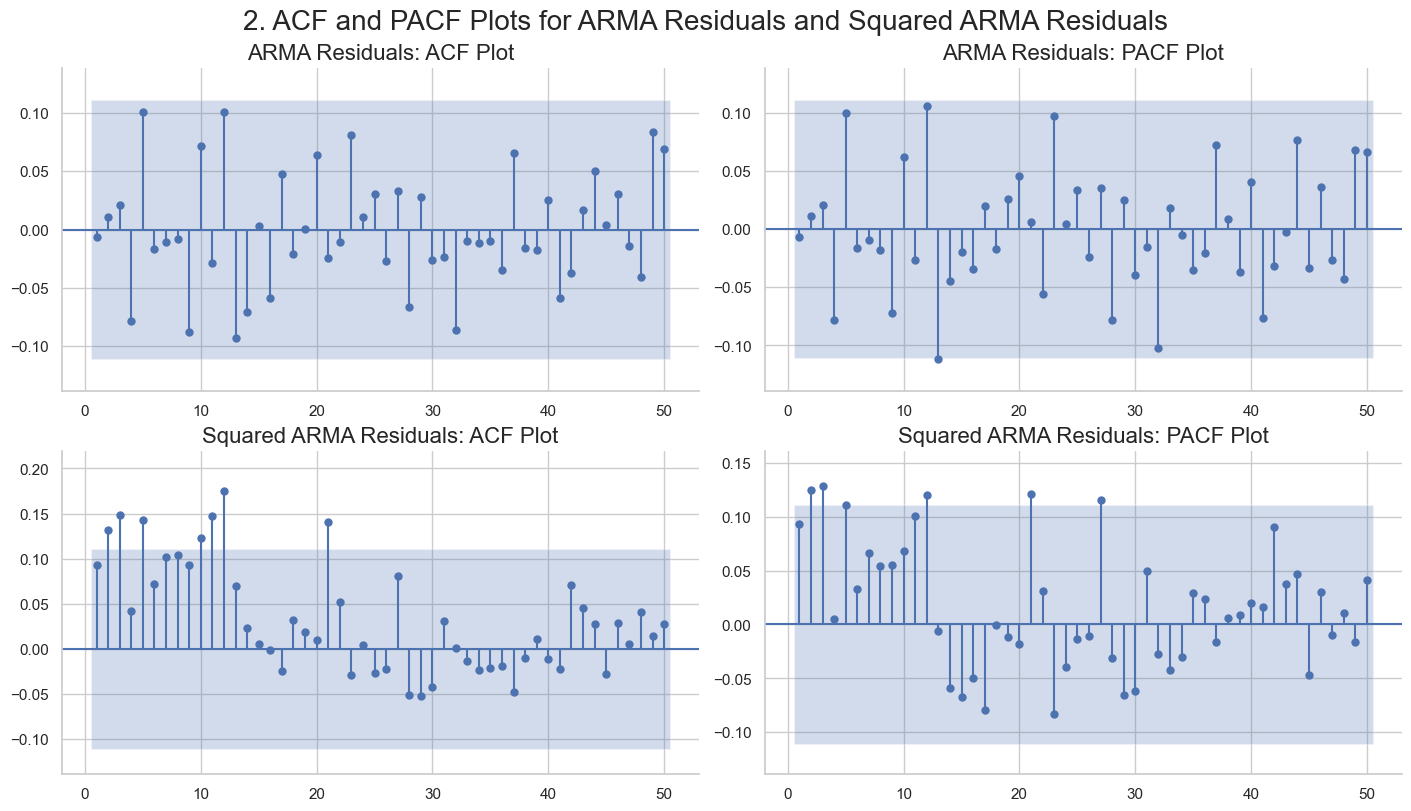

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals, forecast_1step = arma_fit(
    r2, ar_lags=[1,2,3], ma_lags=0,verbose=True, label="Period 2"
)

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(residuals, lags=50, alpha=0.05, ax=axes[0, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0, 0].set_title("ARMA Residuals: ACF Plot", fontsize=16)

# PACF of ARMA Residuals
plot_pacf(residuals, lags=50, alpha=0.05, ax=axes[0, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0, 1].set_title("ARMA Residuals: PACF Plot", fontsize=16)

# ACF of squared ARMA Residuals
plot_acf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1, 0].set_title("Squared ARMA Residuals: ACF Plot", fontsize=16)

# PACF of squared ARMA Residuals
plot_pacf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1, 1].set_title("Squared ARMA Residuals: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("2. ACF and PACF Plots for ARMA Residuals and Squared ARMA Residuals", fontsize=20)
plt.show()


Period 2 – GARCH(1,1) Summary
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.003
Vol Model:                      GARCH   Log-Likelihood:                505.076
Distribution:                  Normal   AIC:                          -1004.15
Method:            Maximum Likelihood   BIC:                          -992.913
                                        No. Observations:                  313
Date:                Thu, Feb 19 2026   Df Residuals:                      313
Time:                        13:33:15   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      5.5943e-05  3

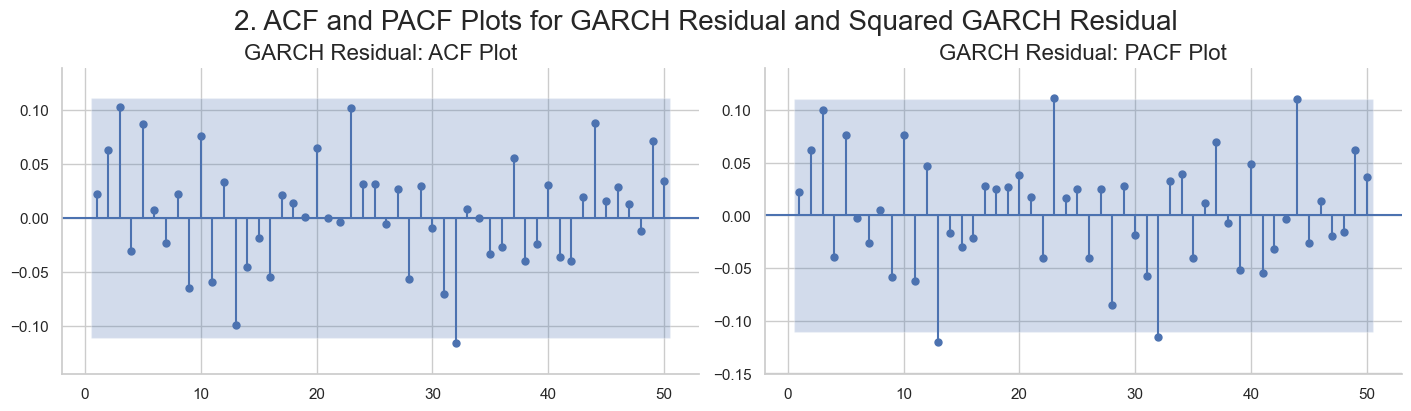

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
resid, vol1forecast = garch_fit(residuals, p =1, q=1, verbose=True, label="Period 2")

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# ACF of GARCH Residual
plot_acf(resid, lags=50, alpha=0.05, ax=axes[0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0].set_title("GARCH Residual: ACF Plot", fontsize=16)

# PACF of GARCH Residual
plot_pacf(resid, lags=50, alpha=0.05, ax=axes[1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1].set_title("GARCH Residual: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("2. ACF and PACF Plots for GARCH Residual and Squared GARCH Residual", fontsize=20)
plt.show()

In [ ]:
from scipy import stats

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# --- QQ Plot ---
(osm, osr), (slope, intercept, r) = stats.probplot(resid, dist="norm")
axes[0].scatter(osm, osr, color="steelblue", alpha=0.6, s=15, label="Residuals")
axes[0].plot(osm, slope * np.array(osm) + intercept, color="crimson", lw=2, label="Reference line")
axes[0].set_title("QQ Plot of GARCH Residuals", fontsize=16)
axes[0].set_xlabel("Theoretical Quantiles", fontsize=12)
axes[0].set_ylabel("Sample Quantiles", fontsize=12)
axes[0].legend()

# --- Histogram + Normal Fit ---
axes[1].hist(resid, bins=50, density=True, color="steelblue", alpha=0.5, label="Residuals")
x_range = np.linspace(resid.min(), resid.max(), 300)
axes[1].plot(x_range, stats.norm.pdf(x_range, resid.mean(), resid.std()),
             color="crimson", lw=2, linestyle="--", label="Normal Fit")
axes[1].set_title("Histogram + Normal Fit of GARCH Residuals", fontsize=16)
axes[1].set_xlabel("Residuals", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)
axes[1].legend()

sns.despine()
plt.suptitle("GARCH Residual Diagnostic Plots", fontsize=20)
plt.show()

# --- Normality Tests ---
jb_stat, jb_p = stats.jarque_bera(resid)
sw_stat, sw_p = stats.shapiro(resid)
ks_stat, ks_p = stats.kstest(resid, 'norm', args=(resid.mean(), resid.std()))

print("=" * 45)
print(f"{'Normality Tests':^45}")
print("=" * 45)
print(f"{'Test':<25} {'Statistic':>8} {'p-value':>10}")
print("-" * 45)
print(f"{'Jarque-Bera':<25} {jb_stat:>8.4f} {jb_p:>10.4f}")
print(f"{'Shapiro-Wilk':<25} {sw_stat:>8.4f} {sw_p:>10.4f}")
print(f"{'KS Test':<25} {ks_stat:>8.4f} {ks_p:>10.4f}")
print("=" * 45)

## Rolling Window

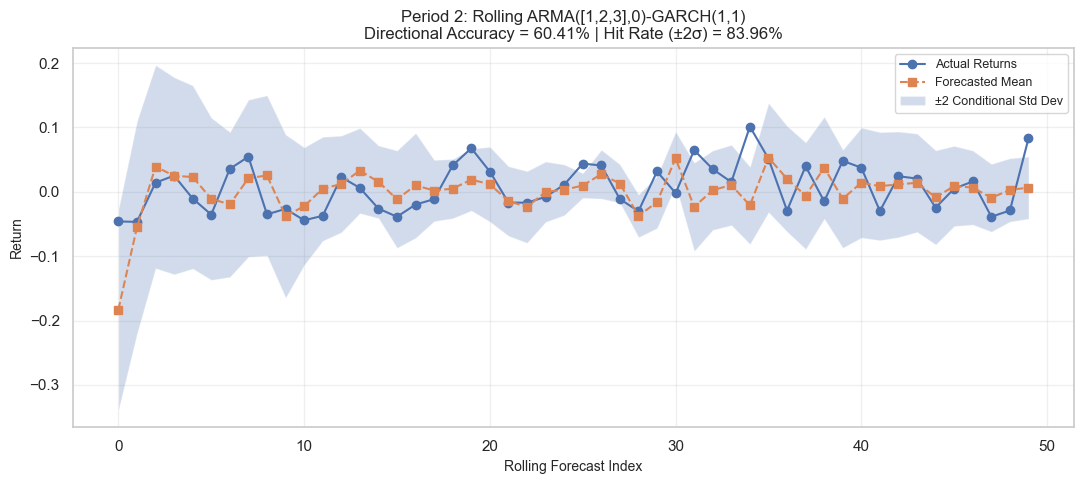


Full Sample Metrics:
Directional Accuracy: 60.41%
Hit Rate (±2σ): 83.96%
Total forecasts: 293


In [31]:
something = plot_arma_garch_forecasts(
    r2, ar_lags=[1,2,3], ma_lags=0, p=1, q=1, window=20,
    title="Period 2: Rolling ARMA([1,2,3],0)-GARCH(1,1)",n_plot=50)

## Cross-Validation

In [18]:
# After your arma_fit / garch_fit / plot calls, run CV:
best_spec, cv_results = cross_validate_arma_garch(
    r2,
    candidate_ar_lags = [1,2,3],   # subsets tried: [], [1], [4], [1,4]
    candidate_ma_lags = [1,2],        # no MA candidates → only [] tried
    garch_orders      = [(1, 1)],  # as per your use-case
    window            = 20,
    verbose           = True
)

Series length  : 313
Train samples  : 250  (indices 0–249)
Test  samples  : 63  (indices 250–312)
Rolling window : 20

Total specifications to evaluate: 32

[  1/32] AR[]-MA[]-GARCH(1,1)                Train DA = 0.00%
[  2/32] AR[]-MA[1]-GARCH(1,1)               Train DA = 63.48%
[  3/32] AR[]-MA[2]-GARCH(1,1)               Train DA = 51.30%
[  4/32] AR[]-MA[1, 2]-GARCH(1,1)            Train DA = 59.13%
[  5/32] AR[1]-MA[]-GARCH(1,1)               Train DA = 57.83%
[  6/32] AR[1]-MA[1]-GARCH(1,1)              Train DA = 59.13%
[  7/32] AR[1]-MA[2]-GARCH(1,1)              Train DA = 60.43%
[  8/32] AR[1]-MA[1, 2]-GARCH(1,1)           Train DA = 58.26%
[  9/32] AR[2]-MA[]-GARCH(1,1)               Train DA = 53.48%
[ 10/32] AR[2]-MA[1]-GARCH(1,1)              Train DA = 56.52%
[ 11/32] AR[2]-MA[2]-GARCH(1,1)              Train DA = 47.83%
[ 12/32] AR[2]-MA[1, 2]-GARCH(1,1)           Train DA = 56.96%
[ 13/32] AR[3]-MA[]-GARCH(1,1)               Train DA = 53.91%
[ 14/32] AR[3]-MA[1]-GARC

# Period 3

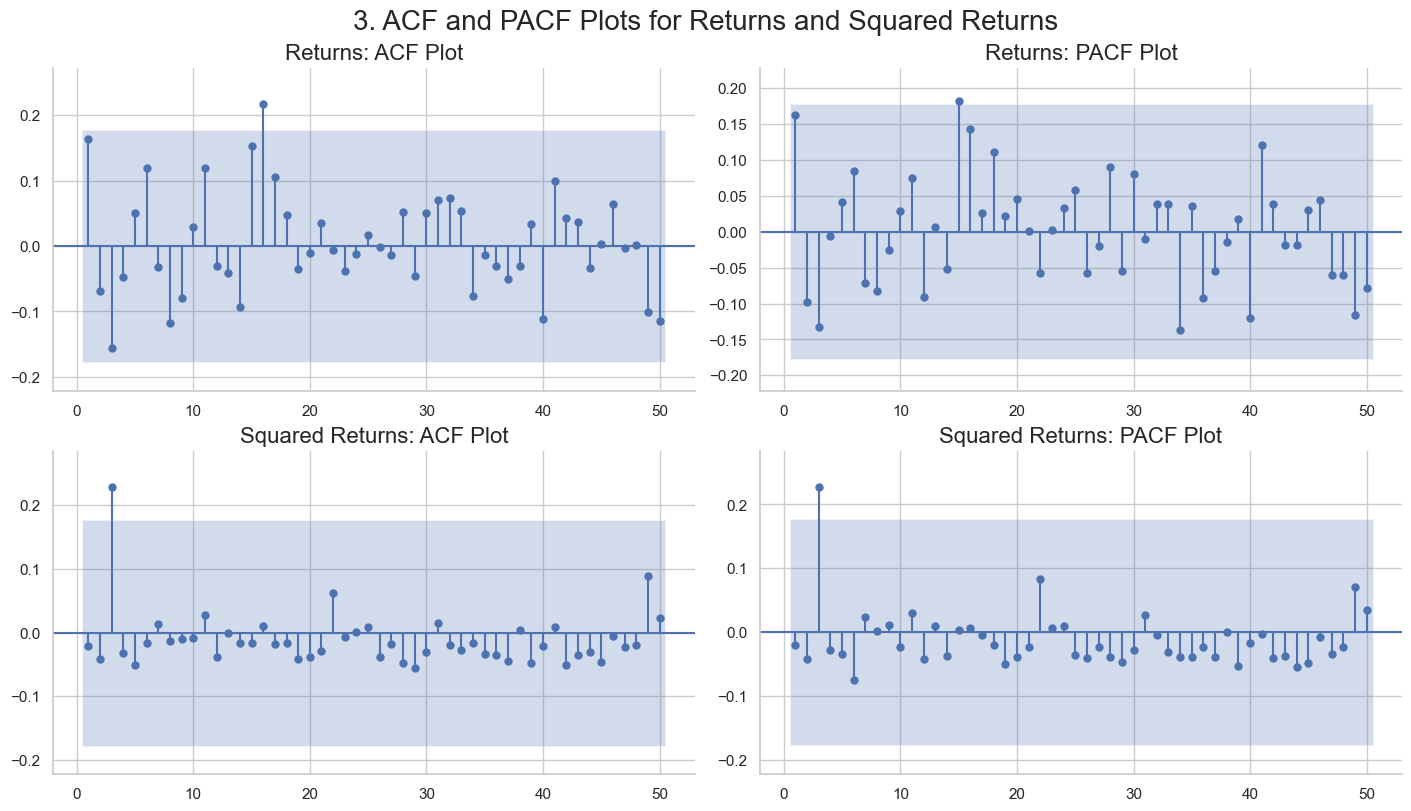

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(r3, lags=50, alpha=0.05, ax=axes[0,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0,0].set_title("Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r3, lags=50, alpha=0.05, ax=axes[0,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0,1].set_title("Returns: PACF Plot", fontsize=16)

# ACF of returns
plot_acf(r3**2, lags=50, alpha=0.05, ax=axes[1,0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1,0].set_title("Squared Returns: ACF Plot", fontsize=16)

# PACF of returns
plot_pacf(r3**2, lags=50, alpha=0.05, ax=axes[1,1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1,1].set_title("Squared Returns: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("3. ACF and PACF Plots for Returns and Squared Returns", fontsize=20)
plt.savefig('pyplots/acf-pacf3.png')
plt.show()


Period 3 – ARMA with AR lags [1], MA lags 0
                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                  122
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 176.155
Date:                Thu, 19 Feb 2026   AIC                           -348.309
Time:                        13:43:07   BIC                           -342.718
Sample:                    01-07-2018   HQIC                          -346.038
                         - 05-03-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1790      0.091      1.957      0.050      -0.000       0.358
sigma2         0.0032      0.000     15.488      0.000       0.003       0.004
Ljung-B

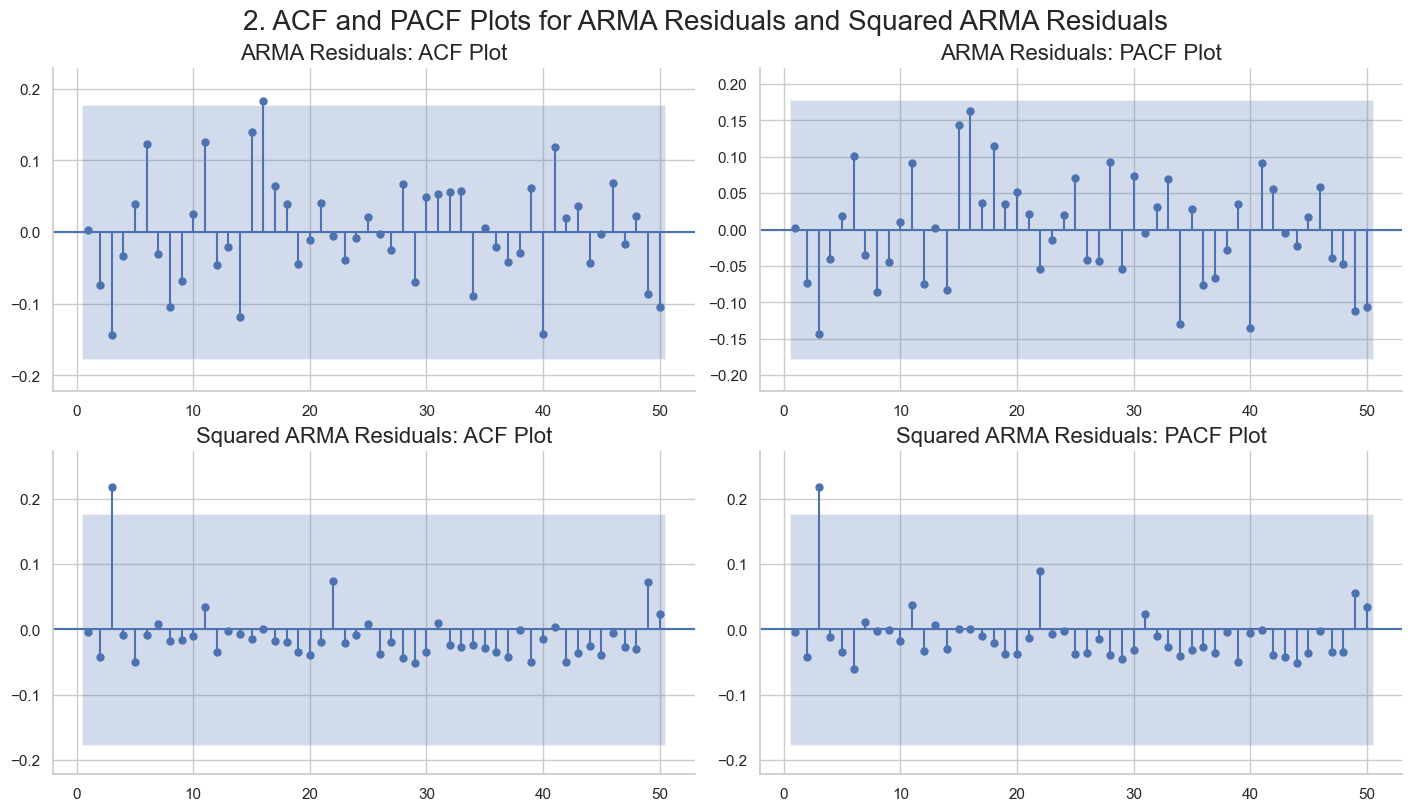

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals, forecast_1step = arma_fit(
    r3, ar_lags=[1], ma_lags=0,verbose=True, label="Period 3"
)

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# ACF of returns
plot_acf(residuals, lags=50, alpha=0.05, ax=axes[0, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0, 0].set_title("ARMA Residuals: ACF Plot", fontsize=16)

# PACF of ARMA Residuals
plot_pacf(residuals, lags=50, alpha=0.05, ax=axes[0, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[0, 1].set_title("ARMA Residuals: PACF Plot", fontsize=16)

# ACF of squared ARMA Residuals
plot_acf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[1, 0].set_title("Squared ARMA Residuals: ACF Plot", fontsize=16)

# PACF of squared ARMA Residuals
plot_pacf(residuals**2, lags=50, alpha=0.05, ax=axes[1, 1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1, 1].set_title("Squared ARMA Residuals: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("2. ACF and PACF Plots for ARMA Residuals and Squared ARMA Residuals", fontsize=20)
plt.show()


Period 3 – GARCH(1,1) Summary
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.008
Vol Model:                      GARCH   Log-Likelihood:                178.230
Distribution:                  Normal   AIC:                          -350.459
Method:            Maximum Likelihood   BIC:                          -342.047
                                        No. Observations:                  122
Date:                Thu, Feb 19 2026   Df Residuals:                      122
Time:                        13:43:08   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      6.9019e-04  4

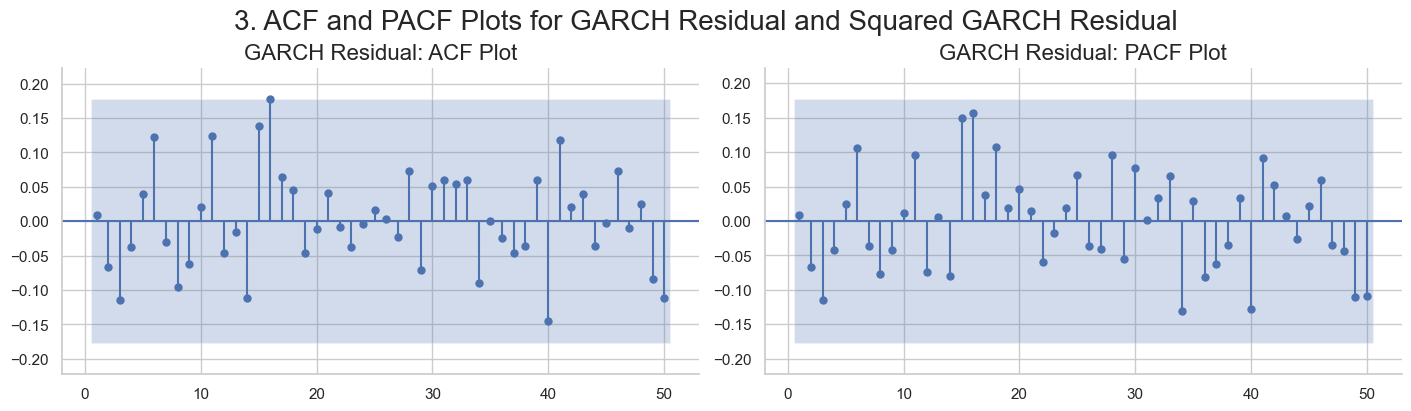

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
resid, vol1forecast = garch_fit(residuals, p =1, q=1, verbose=True, label="Period 3")

# Set seaborn theme
sns.set_theme(style="whitegrid")

# Create 2x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# ACF of GARCH Residual
plot_acf(resid, lags=50, alpha=0.05, ax=axes[0], use_vlines=True,
         zero=False, auto_ylims=True, bartlett_confint=False)
axes[0].set_title("GARCH Residual: ACF Plot", fontsize=16)

# PACF of GARCH Residual
plot_pacf(resid, lags=50, alpha=0.05, ax=axes[1], use_vlines=True,
          zero=False, auto_ylims=True)
axes[1].set_title("GARCH Residual: PACF Plot", fontsize=16)

# Apply Seaborn-style titles and layout
sns.despine()
plt.suptitle("3. ACF and PACF Plots for GARCH Residual and Squared GARCH Residual", fontsize=20)
plt.show()

## Rolling Window

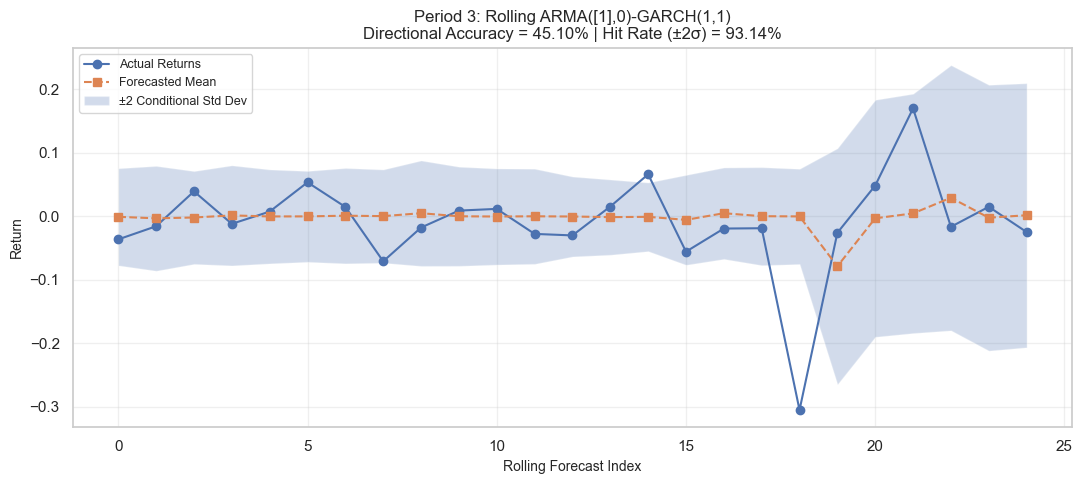


Full Sample Metrics:
Directional Accuracy: 45.10%
Hit Rate (±2σ): 93.14%
Total forecasts: 102


In [33]:
something = plot_arma_garch_forecasts(
    r3, ar_lags=[1], ma_lags=0, p=1, q=1, window=20,
    title="Period 3: Rolling ARMA([1],0)-GARCH(1,1)",n_plot=25)

## Cross-validation

In [23]:
# After your arma_fit / garch_fit / plot calls, run CV:
best_spec, cv_results = cross_validate_arma_garch(
    r3,
    candidate_ar_lags = [1,2,3],   # subsets tried: [], [1], [4], [1,4]
    candidate_ma_lags = [],        # no MA candidates → only [] tried
    garch_orders      = [(1, 1)],  # as per your use-case
    window            = 20,
    verbose           = True
)

Series length  : 122
Train samples  : 97  (indices 0–96)
Test  samples  : 25  (indices 97–121)
Rolling window : 20

Total specifications to evaluate: 8

[  1/8] AR[]-MA[]-GARCH(1,1)                Train DA = 0.00%
[  2/8] AR[1]-MA[]-GARCH(1,1)               Train DA = 48.05%
[  3/8] AR[2]-MA[]-GARCH(1,1)               Train DA = 57.14%


c:\Users\chakr\AppData\Local\Programs\Python\Python310\lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


[  4/8] AR[3]-MA[]-GARCH(1,1)               Train DA = 46.75%
[  5/8] AR[1, 2]-MA[]-GARCH(1,1)            Train DA = 57.14%
[  6/8] AR[1, 3]-MA[]-GARCH(1,1)            Train DA = 55.84%
[  7/8] AR[2, 3]-MA[]-GARCH(1,1)            Train DA = 50.65%
[  8/8] AR[1, 2, 3]-MA[]-GARCH(1,1)         Train DA = 50.65%

Best spec       : AR[2]-MA[]-GARCH(1,1)
Train DA        : 57.14%
Test  DA        : 64.00%  (25 test forecasts)
Test  Hit Rate  : 92.00%  (±2σ interval)

All specs by Train DA:
                      label  train_da  test_da  test_hit_rate  test_nobs
      AR[2]-MA[]-GARCH(1,1)  0.571429     0.64           0.92         25
   AR[1, 2]-MA[]-GARCH(1,1)  0.571429     0.68           0.92         25
   AR[1, 3]-MA[]-GARCH(1,1)  0.558442     0.44           0.80         25
   AR[2, 3]-MA[]-GARCH(1,1)  0.506494     0.56           0.88         25
AR[1, 2, 3]-MA[]-GARCH(1,1)  0.506494     0.60           0.84         25
      AR[1]-MA[]-GARCH(1,1)  0.480519     0.36           0.92         25
  